# 텍스트 프롬프트 제로샷 분류 (NPU)

PE는 CLIP 계열이라 **이미지 임베딩 ↔ 텍스트 프롬프트 임베딩의 코사인 유사도**로 분류 문제를 푼다.
NPU가 이미지 임베딩을, 미리 인코딩된 `text_features.json`이 프롬프트 임베딩을 담당.

```
image --(NPU hybrid)--> (1024) ─┐
                                ├─ cosine → 가장 높은 클래스로 분류
prompts --(사전 인코딩)--> (N,1024) ┘
```
> 커널: `pe_npu_host`. 텍스트 피쳐는 HF `PIA-SPACE-LAB/PE-Core-L14-336`에서 자동 다운로드.

In [1]:
import os, sys, glob, json
import numpy as np, torch
sys.path.insert(0, os.path.abspath(".."))
import pe_npu
from huggingface_hub import hf_hub_download

INDEX = {0:"normal",1:"falldown",2:"fire",3:"smoke",4:"smoking",5:"esfalldown",6:"elvfalldown"}
print("pe_npu OK")

pe_npu OK


/home/gpuadmin/miniconda3/envs/pe_npu_host/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. NPU 추론기 + 텍스트 프롬프트 임베딩 로드

In [2]:
model = pe_npu.MXQInferenceHybrid.from_hf()       # MXQ + pool head 자동 다운로드

p = hf_hub_download(repo_id="PIA-SPACE-LAB/PE-Core-L14-336", filename="text_features.json")
items = json.load(open(p))
cls = np.array([it["class"] for it in items])
txt = torch.tensor([it["feature"] for it in items], dtype=torch.float32)
txt = txt / txt.norm(dim=-1, keepdim=True)
print(f"프롬프트 {len(cls)}개, 클래스 {sorted(set(int(c) for c in cls))}")

I0623 08:31:29.474 2333746 model_impl.cc:1025] Model constructed. (/home/gpuadmin/.cache/huggingface/hub/models--PIA-SPACE-LAB--MXQ_NPU/snapshots/6e2fa2dd0f0a3f270e3762a183af26a84767f92a/pe_feat.mxq) 
I0623 08:31:29.668 2333746 model_impl.cc:1357] Model launched.


프롬프트 13449개, 클래스 [0, 1, 2, 3, 5]


## 2. 이미지별 제로샷 분류

In [3]:
paths = sorted(glob.glob("images/*.jpg"))
def classify(path):
    x = pe_npu.preprocess_image(path)
    emb = torch.from_numpy(np.asarray(model.infer(x[None]))).float().reshape(-1)
    emb = emb / emb.norm()
    sim = emb @ txt.T
    per_class = {int(c): float(sim[torch.from_numpy(cls==c)].max()) for c in set(int(v) for v in cls)}
    pred = max(per_class, key=per_class.get)
    return pred, per_class

results = {}
for pth in paths:
    pred, sc = classify(pth); results[os.path.basename(pth)] = (pred, sc)
    print(f"{os.path.basename(pth):14s} → {INDEX[pred]:10s}  "
          + " ".join(f"{INDEX[c]}={s:.3f}" for c,s in sorted(sc.items(), key=lambda kv:-kv[1])[:3]))

bus.jpg        → normal      normal=0.214 smoke=0.139 fire=0.130


cat1.jpg       → esfalldown  esfalldown=0.169 normal=0.152 falldown=0.104


cat2.jpg       → normal      normal=0.188 smoke=0.137 fire=0.127


dog.jpg        → normal      normal=0.173 smoke=0.167 fire=0.118


falldown.jpg   → falldown    falldown=0.293 fire=0.276 smoke=0.275


fire.jpg       → smoke       smoke=0.267 fire=0.257 normal=0.238


pizza.jpg      → normal      normal=0.149 smoke=0.115 fire=0.102


smoke.jpg      → smoke       smoke=0.282 normal=0.265 fire=0.260


## 3. 클래스별 유사도 시각화 (이벤트 이미지)

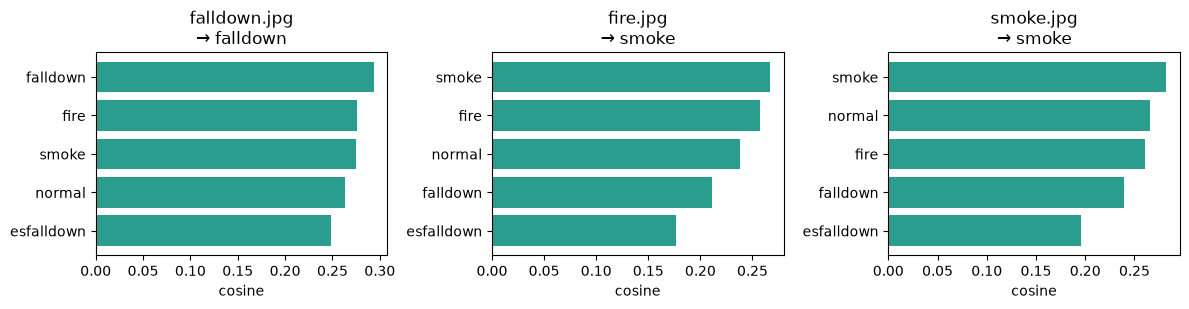

핵심: 이미지 임베딩(NPU) vs 프롬프트 임베딩 유사도로 분류 = CLIP 제로샷 retrieval


In [4]:
import matplotlib.pyplot as plt
ev = [n for n in results if n.split('.')[0] in ("fire","smoke","falldown")]
if ev:
    fig, axes = plt.subplots(1, len(ev), figsize=(4*len(ev),3.2))
    if len(ev)==1: axes=[axes]
    for ax,n in zip(axes, ev):
        pred, sc = results[n]
        cs = sorted(sc.items(), key=lambda kv:-kv[1])
        ax.barh([INDEX[c] for c,_ in cs][::-1], [s for _,s in cs][::-1], color="#2a9d8f")
        ax.set_title(f"{n}\n→ {INDEX[pred]}"); ax.set_xlabel("cosine")
    plt.tight_layout(); plt.show()
print("핵심: 이미지 임베딩(NPU) vs 프롬프트 임베딩 유사도로 분류 = CLIP 제로샷 retrieval")